# LiftingLine Transition Drag Polars

This notebook checks the `LiftingLine` NeuralFoil transition inputs on a generic tapered wing.

In [4]:
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

airplane = asb.Airplane(
    wings=[
        asb.Wing(
            name="Generic Wing",
            symmetric=True,
            xsecs=[
                asb.WingXSec(
                    xyz_le=[0.0, 0.0, 0.0],
                    chord=1.5,
                    airfoil=asb.Airfoil("naca2412"),
                ),
                asb.WingXSec(
                    xyz_le=[0.35, 5.0, 0.25],
                    chord=0.75,
                    airfoil=asb.Airfoil("naca2412"),
                ),
            ],
        )
    ],
    xyz_ref=[0.35, 0.0, 0.0],
    s_ref=11.25,
    c_ref=1.125,
    b_ref=10.0,
)

alphas = np.linspace(-5, 20, 26)
velocity = 45.0

cases = {
    "ncrit=9": dict(n_crit=9.0),
    "ncrit=5": dict(n_crit=5.0),
    "xtr_top=0.1, xtr_bottom=0.1": dict(xtr_upper=0.1, xtr_lower=0.1),
}

In [5]:
def run_lifting_line_polar(case_kwargs):
    aero_by_alpha = []

    for alpha in alphas:
        aero = asb.LiftingLine(
            airplane=airplane,
            op_point=asb.OperatingPoint(
                velocity=velocity,
                alpha=alpha,
            ),
            model_size="small",
            spanwise_resolution=6,
            **case_kwargs,
        ).run()
        aero_by_alpha.append(aero)

    return {
        "alpha": np.array(alphas),
        "CL": np.array([aero["CL"] for aero in aero_by_alpha]),
        "CD": np.array([aero["CD"] for aero in aero_by_alpha]),
        "Cm": np.array([aero["Cm"] for aero in aero_by_alpha]),
    }

polars = {
    label: run_lifting_line_polar(case_kwargs)
    for label, case_kwargs in cases.items()
}

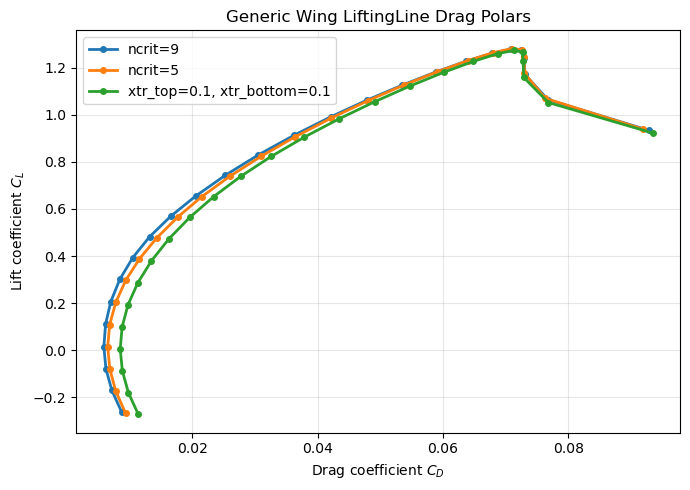

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

for label, polar in polars.items():
    ax.plot(
        polar["CD"],
        polar["CL"],
        marker="o",
        linewidth=2,
        markersize=4,
        label=label,
    )

ax.set_xlabel("Drag coefficient $C_D$")
ax.set_ylabel("Lift coefficient $C_L$")
ax.set_title("Generic Wing LiftingLine Drag Polars")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
for label, polar in polars.items():
    min_cd_index = np.argmin(polar["CD"])
    print(
        f"{label:32s}  min CD = {polar['CD'][min_cd_index]:.5f} "
        f"at CL = {polar['CL'][min_cd_index]:.3f}"
    )

ncrit=9                           min CD = 0.00587 at CL = 0.014
ncrit=5                           min CD = 0.00648 at CL = 0.014
xtr_top=0.1, xtr_bottom=0.1       min CD = 0.00848 at CL = 0.005
